In [26]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [27]:
import sqlite3
conn = sqlite3.connect(r"D:\Universety\Level 2\S2\Data Mining\project\data minig proj\jobs.db")
df = pd.read_sql_query("SELECT * FROM job_offers", conn)
conn.close()
print("Loaded from SQLite! Rows:", len(df))


Loaded from SQLite! Rows: 763


In [28]:
df = df[df["job title"]    != "Unknown"]
df = df[df["company name"] != "Unknown"]
df = df[df["location"]     != "Unknown"]

print("After cleaning, rows remaining:", len(df))

After cleaning, rows remaining: 678


In [29]:
def get_category(title):
    title = str(title).lower()
    if "data engineer"    in title: return "Data Engineering"
    if "data scientist"   in title: return "Data Science"
    if "data analyst"     in title: return "Data Analysis"
    if "machine learning" in title: return "ML / AI"
    if "ai"               in title: return "AI / ML"
    if "devops"           in title: return "DevOps"
    if "software"         in title: return "Software Eng"
    if "developer"        in title: return "Development"
    if "cloud"            in title: return "Cloud"
    return "Other"

df["category"] = df["job title"].apply(get_category)

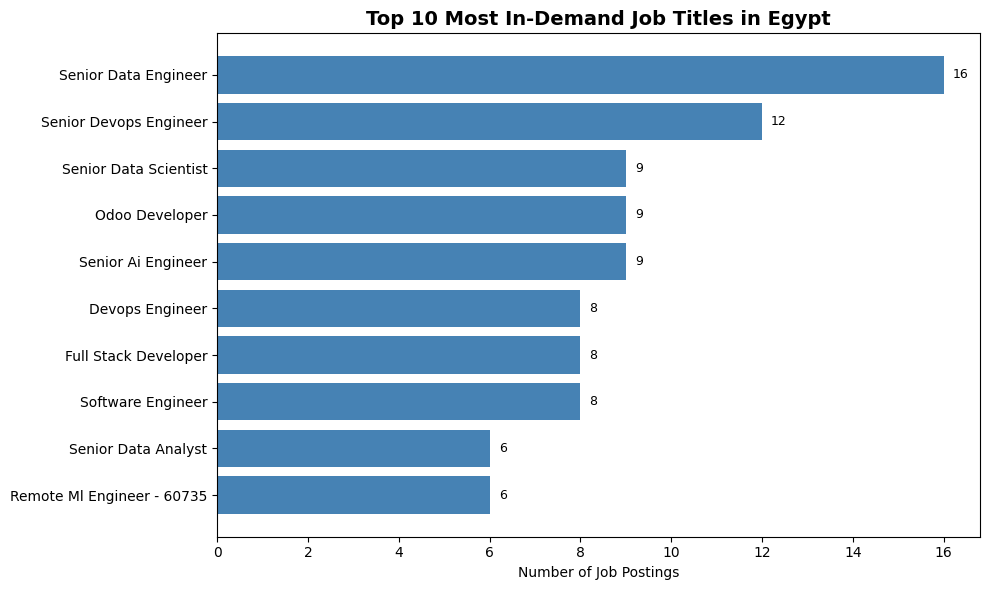

Plot 1 saved!


In [30]:
top_jobs = df["job title"].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_jobs.index[::-1], top_jobs.values[::-1], color="steelblue")
plt.title("Top 10 Most In-Demand Job Titles in Egypt", fontsize=14, fontweight="bold")
plt.xlabel("Number of Job Postings")

# Add number labels on each bar
for i, v in enumerate(top_jobs.values[::-1]):
    plt.text(v + 0.2, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.savefig("plot1_top_job_titles.png", dpi=150)
plt.show()
print("Plot 1 saved!")

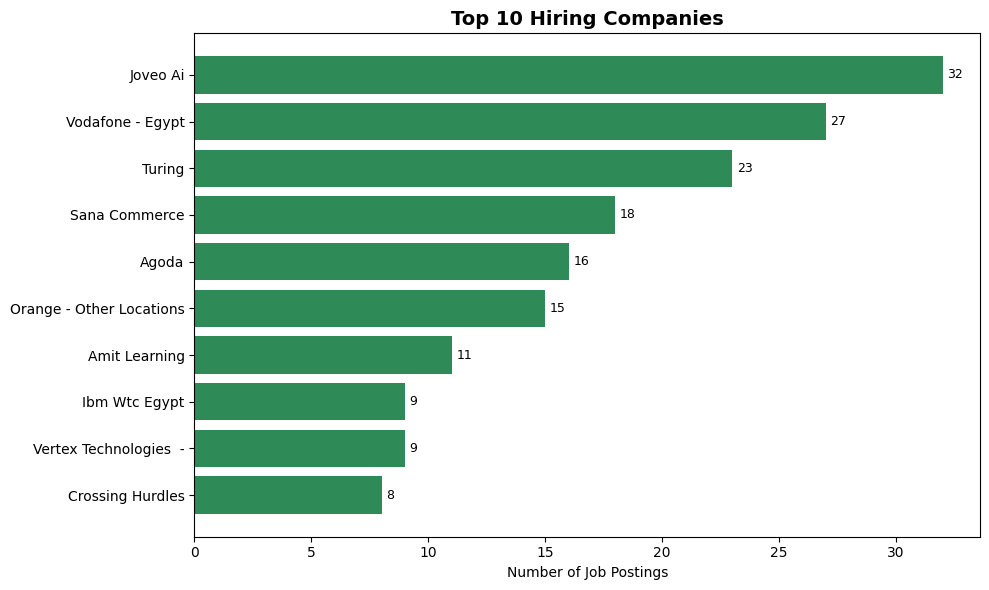

Plot 2 saved!


In [31]:
top_companies = df["company name"].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_companies.index[::-1], top_companies.values[::-1], color="seagreen")
plt.title("Top 10 Hiring Companies", fontsize=14, fontweight="bold")
plt.xlabel("Number of Job Postings")

for i, v in enumerate(top_companies.values[::-1]):
    plt.text(v + 0.2, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.savefig("plot2_top_companies.png", dpi=150)
plt.show()
print("Plot 2 saved!")

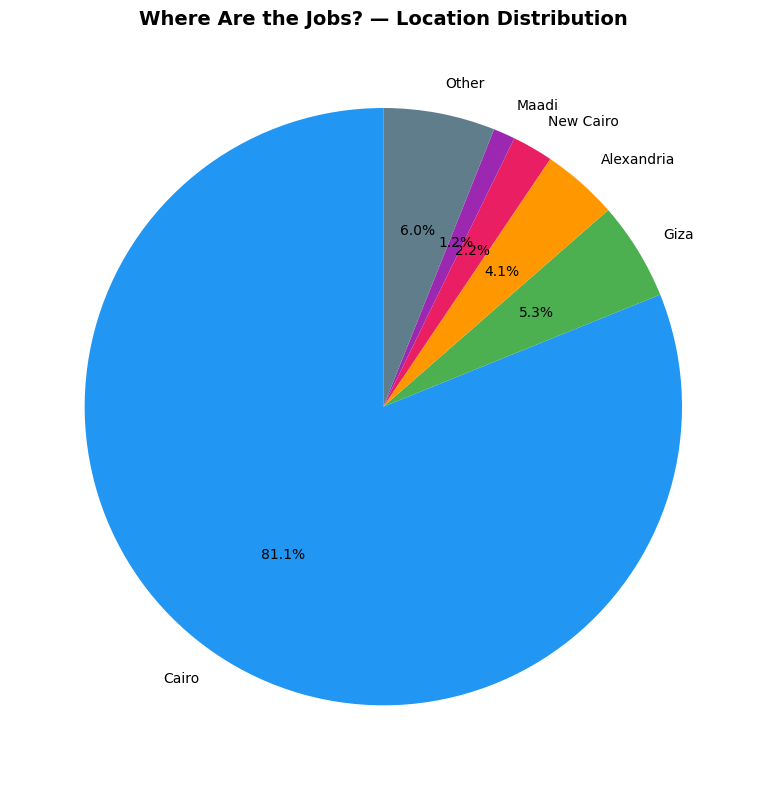

Plot 3 saved!


In [32]:
location_counts = df["location"].value_counts()

# Keep top 5 cities, group the rest as "Other"
top5     = location_counts.head(5)
other    = location_counts.iloc[5:].sum()
pie_data = pd.concat([top5, pd.Series({"Other": other})])

plt.figure(figsize=(8, 8))
plt.pie(
    pie_data.values,
    labels=pie_data.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2196F3", "#4CAF50", "#FF9800", "#E91E63", "#9C27B0", "#607D8B"]
)
plt.title("Where Are the Jobs? — Location Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot3_location_pie.png", dpi=150)
plt.show()
print("Plot 3 saved!")


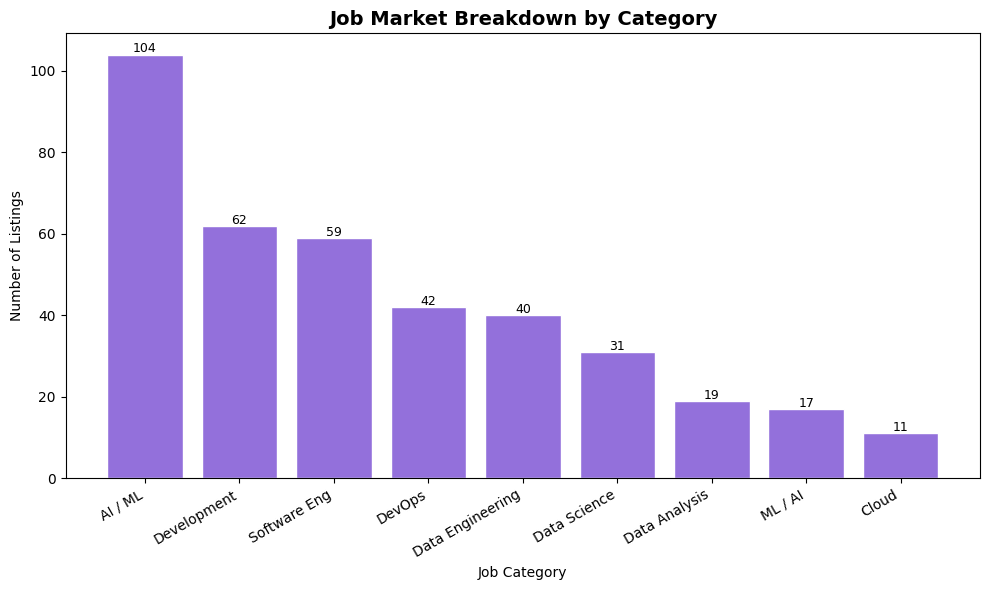

Plot 4 saved!


In [33]:
category_counts = df[df["category"] != "Other"]["category"].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(category_counts.index, category_counts.values, color="mediumpurple", edgecolor="white")
plt.title("Job Market Breakdown by Category", fontsize=14, fontweight="bold")
plt.xlabel("Job Category")
plt.ylabel("Number of Listings")
plt.xticks(rotation=30, ha="right")

for i, v in enumerate(category_counts.values):
    plt.text(i, v + 0.5, str(v), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("plot4_job_categories.png", dpi=150)
plt.show()
print("Plot 4 saved!")

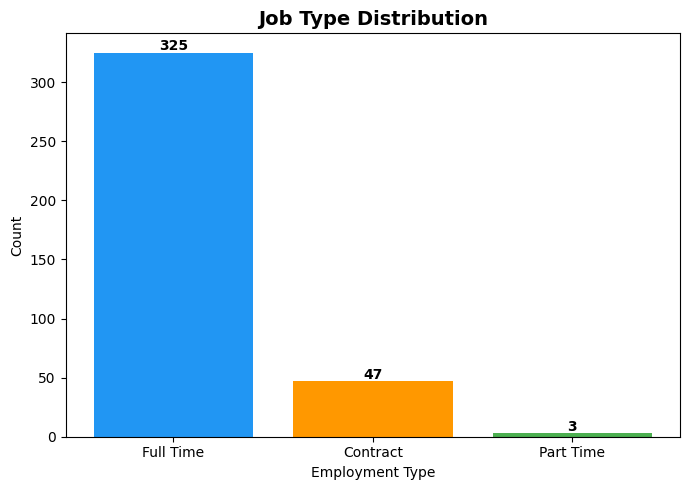

Plot 5 saved!


In [34]:
job_types     = ["Full Time", "Contract", "Part Time", "Freelance"]
type_counts   = df[df["skills"].isin(job_types)]["skills"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(type_counts.index, type_counts.values,
        color=["#2196F3", "#FF9800", "#4CAF50", "#E91E63"])
plt.title("Job Type Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Employment Type")
plt.ylabel("Count")

for i, v in enumerate(type_counts.values):
    plt.text(i, v + 2, str(v), ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("plot5_employment_type.png", dpi=150)
plt.show()
print("Plot 5 saved!")

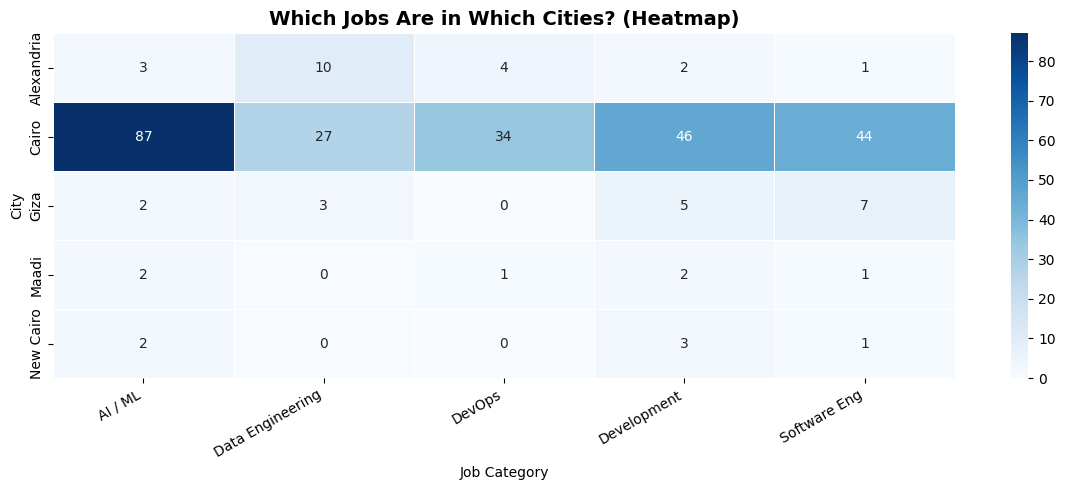

Plot 6 saved!


In [36]:
df_heat = df[df["category"] != "Other"].copy()

top5_cities    = df_heat["location"].value_counts().head(5).index
top5_cats      = df_heat["category"].value_counts().head(5).index
df_heat        = df_heat[df_heat["location"].isin(top5_cities) &
                         df_heat["category"].isin(top5_cats)]

pivot = df_heat.pivot_table(
    index="location",
    columns="category",
    aggfunc="size",
    fill_value=0
)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues",
            linewidths=0.5, linecolor="white")
plt.title("Which Jobs Are in Which Cities? (Heatmap)", fontsize=14, fontweight="bold")
plt.xlabel("Job Category")
plt.ylabel("City")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("plot6_heatmap.png", dpi=150)
plt.show()
print("Plot 6 saved!")